# Single UE / 3 gNB A3 + RX Probability Regression

This notebook tests the two fixed bugs:

- A3 handover now runs inside `MultiGNBWrapper.step()`, so direct radio traces can hand over without `GlobalPPO3GNBEnv`.
- The PF scheduler now re-picks MCS on the realized allocated PRB SNR vector, so high SINR should not produce collapsed `rx_probability`.

The default run is short and deterministic. Increase `SIM_SECONDS` to `300.0` or `5 * 60.0` for a long trace.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_nodeb
from multi_gnb_wrapper import MultiGNBWrapper

pd.set_option("display.max_columns", 120)

In [2]:
STEP_DT = 1e-3
SIM_SECONDS = 60
LOG_EVERY = 1

UE_START = (50.0, 0.0)
UE_VELOCITY = (150.0, 0.0)

A3_HYSTERESIS_DB = 1.0
A3_TTT_STEPS = 3

RESULT_DIR = ROOT / "results" / "single_ue_3gnb_a3_rxprob_regression"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
TRACE_CSV = RESULT_DIR / "radio_prb_trace_fixed.csv"

N_STEPS = int(round(SIM_SECONDS / STEP_DT))
N_STEPS

60000

In [3]:
def make_gnbs(seed=1):
    rng = np.random.default_rng(seed)
    specs = [
        (0, 0.0, 0.0),
        (1, 500.0, 0.0),
        (2, 250.0, 450.0),
    ]
    return [
        create_nodeb(
            rng,
            0,
            slots_per_step=1,
            L1_level=False,
            node_id=gnb_id,
            node_x=x,
            node_y=y,
            coverage_radius=900,
            n_prbs_override=100,
            wrapper_managed_mobile_slices=True,
        )
        for gnb_id, x, y in specs
    ]


def make_env():
    gnbs = make_gnbs()
    env = MultiGNBWrapper(
        gnbs,
        step_dt=STEP_DT,
        mobility_dt=STEP_DT,
        radio_substeps=1,
        max_episode_steps=N_STEPS,
        handover_ttt=A3_TTT_STEPS,
        a3_hysteresis_db=A3_HYSTERESIS_DB,
        disconnect_sinr_db=-100.0,
        ue_traffic_profiles={
            "eMBB": {
                "traffic_model": "fixed_packet_cbr",
                "packet_size_bits": 3000.0,
                "bit_rate": 2_000_000.0,
            }
        },
    )
    ue_id = env.add_ue(
        x=UE_START[0],
        y=UE_START[1],
        vx=UE_VELOCITY[0],
        vy=UE_VELOCITY[1],
        slice_type="eMBB",
    )

    ue = env.get_ue(ue_id)
    for gnb in gnbs:
        gnb.detach_ue(ue_id)
    gnbs[0].attach_ue(ue)
    ue.serving_gnb = 0
    ue.connected = True
    return env, ue_id, gnbs


env, ue_id, gnbs = make_env()
ue0 = env.get_ue(ue_id)
initial_topology = {"ue_x": ue0.x, "ue_y": ue0.y, "serving_gnb": ue0.serving_gnb}
initial_topology

{'ue_x': 50.0, 'ue_y': 0.0, 'serving_gnb': 0}

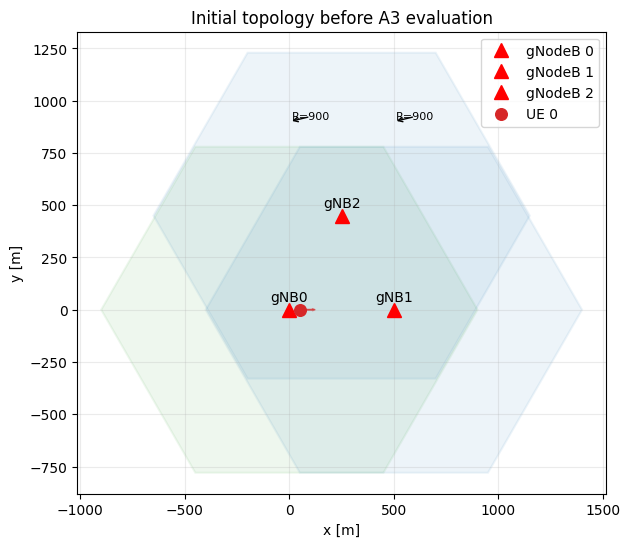

In [4]:
def plot_topology(env, gnbs, ue_id, title):
    ue = env.get_ue(ue_id)
    fig, ax = plt.subplots(figsize=(7, 6))
    for gnb in gnbs:
        color = "tab:green" if int(gnb.id) == int(ue.serving_gnb) else "tab:blue"
        gnb.visualize_coverage(ax=ax, color=color, alpha=0.08, edge_color=color, linewidth=1.5)
        ax.text(gnb.x, gnb.y + 25, f"gNB{gnb.id}", ha="center", va="bottom", fontsize=10)
    ax.scatter([ue.x], [ue.y], c="tab:red", s=70, zorder=10, label=f"UE {ue.id}")
    ax.arrow(ue.x, ue.y, ue.vx * 0.4, ue.vy * 0.4, width=3, color="tab:red", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal", adjustable="box")
    plt.show()


plot_topology(env, gnbs, ue_id, "Initial topology before A3 evaluation")

In [5]:
rows = []
for step in range(N_STEPS):
    _obs, _reward, terminated, truncated, info = env.step(0)
    if step % LOG_EVERY == 0 or terminated or truncated:
        m = env.get_ue_radio_metrics(ue_id)
        ue = env.get_ue(ue_id)
        row = {
            "tick": int(env._step_count),
            "time_s": float(env._step_count * STEP_DT),
            **m,
            "queue_bits": float(ue.queue),
            "handover_count": int(len(env.get_handover_events())),
        }
        for gnb in gnbs:
            lm = env._compute_link_metrics(gnb, ue)
            row[f"g{gnb.id}_rsrp_dbm"] = float(lm["rsrp_dbm"])
            row[f"g{gnb.id}_sinr_db"] = float(lm["sinr_db"])
        rows.append(row)
    if terminated or truncated:
        break

df = pd.DataFrame(rows)
df.to_csv(TRACE_CSV, index=False)
TRACE_CSV, df.shape, env.get_handover_events()

(PosixPath('/home/oussama/Desktop/chech/results/single_ue_3gnb_a3_rxprob_regression/radio_prb_trace_fixed.csv'),
 (60000, 50),
 [{'step': 1387,
   'ue_id': 0,
   'slice_type': 'EMBB',
   'from_gnb': 0,
   'to_gnb': 1,
   'rsrp_serving_dbm': -80.84082623779081,
   'rsrp_target_dbm': -79.788844528044,
   'offset_db': 0.0,
   'controller': 'MultiGNBWrapper'},
  {'step': 18054,
   'ue_id': 0,
   'slice_type': 'EMBB',
   'from_gnb': 1,
   'to_gnb': 0,
   'rsrp_serving_dbm': -80.84082623780131,
   'rsrp_target_dbm': -79.7888445280328,
   'offset_db': 0.0,
   'controller': 'MultiGNBWrapper'},
  {'step': 34721,
   'ue_id': 0,
   'slice_type': 'EMBB',
   'from_gnb': 0,
   'to_gnb': 1,
   'rsrp_serving_dbm': -80.84082623778409,
   'rsrp_target_dbm': -79.78884452805116,
   'offset_db': 0.0,
   'controller': 'MultiGNBWrapper'},
  {'step': 51388,
   'ue_id': 0,
   'slice_type': 'EMBB',
   'from_gnb': 1,
   'to_gnb': 0,
   'rsrp_serving_dbm': -80.84082623780131,
   'rsrp_target_dbm': -79.78884452803

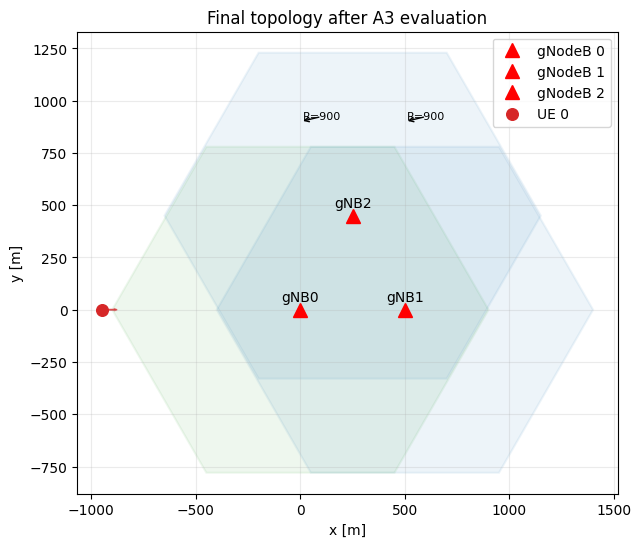

In [6]:
plot_topology(env, gnbs, ue_id, "Final topology after A3 evaluation")

In [7]:
summary = {
    "rows": len(df),
    "sim_seconds": float(df["time_s"].iloc[-1]),
    "handovers": int((df["serving_gnb"].diff().fillna(0) != 0).sum()),
    "final_serving_gnb": int(df["serving_gnb"].iloc[-1]),
    "mean_sinr_db": float(df["sinr_db"].mean()),
    "mean_rx_probability": float(df["rx_probability"].mean()),
    "mean_rx_probability_sinr_gt_15": float(df.loc[df["sinr_db"] > 15, "rx_probability"].mean()),
    "max_allocated_prbs": int(df["allocated_prbs"].max()),
    "mean_used_prbs": float(df["used_prbs"].mean()),
    "mean_wasted_prbs": float(df["wasted_prbs"].mean()),
    "hf_ratios": env.get_handover_failure_ratios(),
    "pp_ratios": env.get_ping_pong_ratios(),
}
summary

{'rows': 60000,
 'sim_seconds': 60.0,
 'handovers': 4,
 'final_serving_gnb': 0,
 'mean_sinr_db': 9.206474082946805,
 'mean_rx_probability': 0.9011315871154977,
 'mean_rx_probability_sinr_gt_15': 0.9875398007217425,
 'max_allocated_prbs': 100,
 'mean_used_prbs': 5.48085,
 'mean_wasted_prbs': 86.18248333333334,
 'hf_ratios': {(0, 1, 'EMBB'): 0.0, (1, 0, 'EMBB'): 0.0},
 'pp_ratios': {(0, 1, 'EMBB'): 0.0, (1, 0, 'EMBB'): 0.0}}

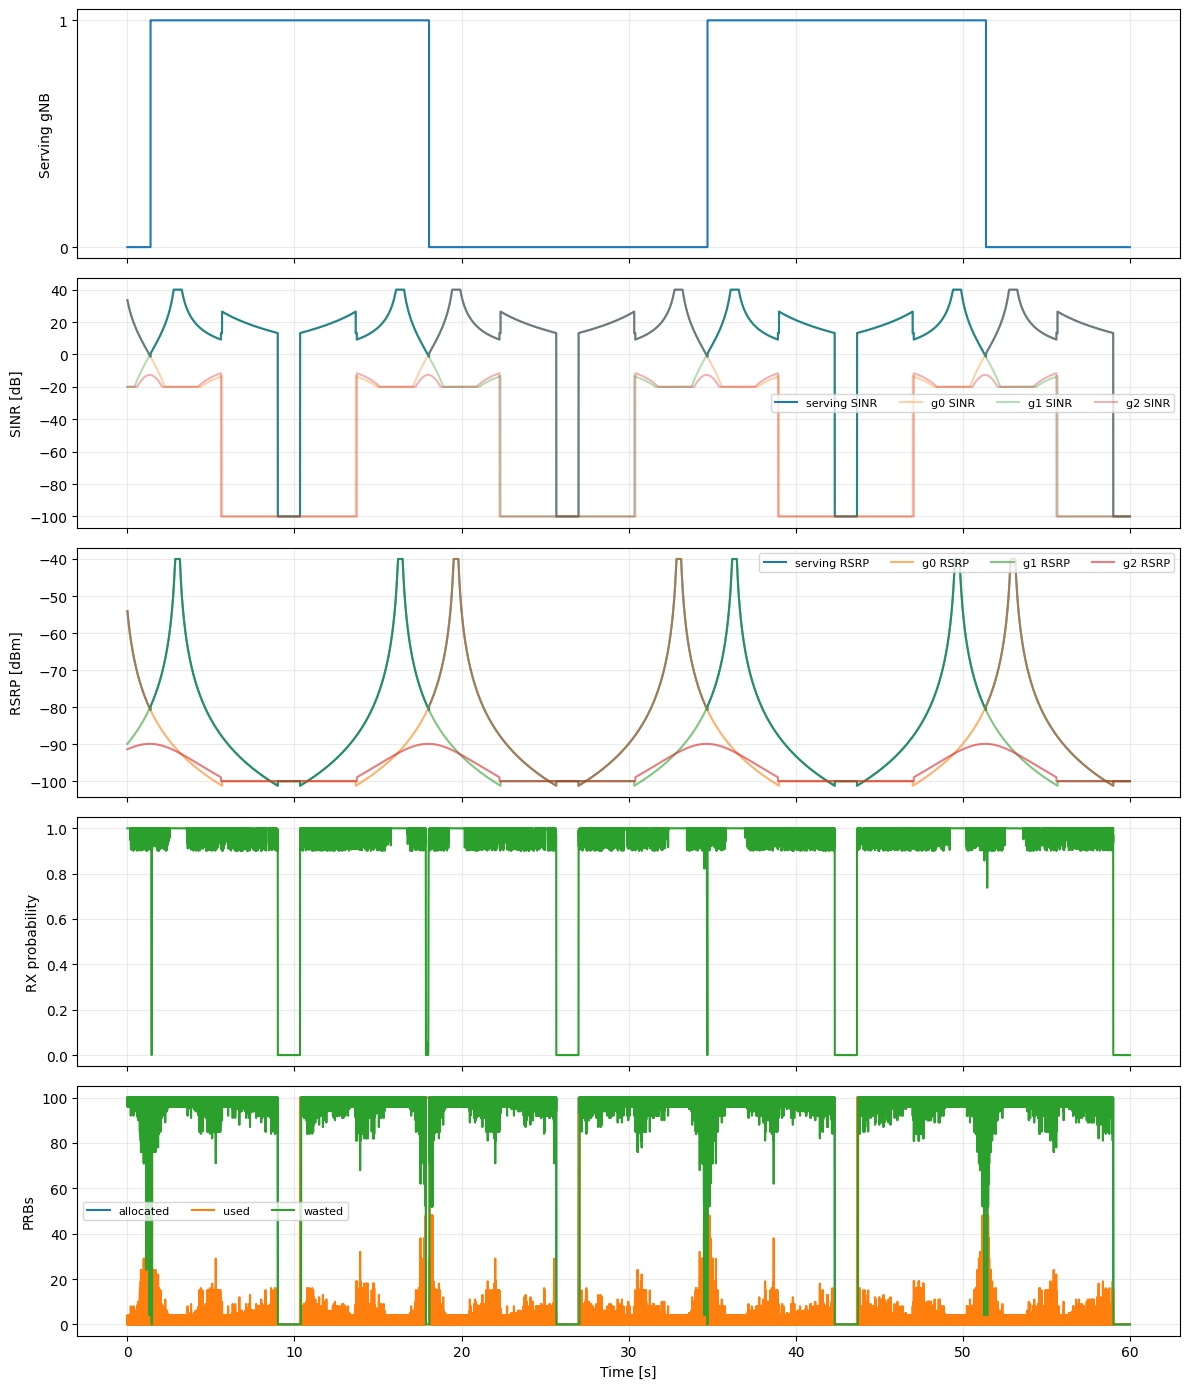

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

axes[0].plot(df["time_s"], df["serving_gnb"], drawstyle="steps-post")
axes[0].set_ylabel("Serving gNB")
axes[0].set_yticks(sorted(df["serving_gnb"].dropna().unique()))

axes[1].plot(df["time_s"], df["sinr_db"], label="serving SINR")
for gnb in gnbs:
    axes[1].plot(df["time_s"], df[f"g{gnb.id}_sinr_db"], alpha=0.35, label=f"g{gnb.id} SINR")
axes[1].set_ylabel("SINR [dB]")
axes[1].legend(ncol=4, fontsize=8)

axes[2].plot(df["time_s"], df["rsrp_dbm"], label="serving RSRP")
for gnb in gnbs:
    axes[2].plot(df["time_s"], df[f"g{gnb.id}_rsrp_dbm"], alpha=0.6, label=f"g{gnb.id} RSRP")
axes[2].set_ylabel("RSRP [dBm]")
axes[2].legend(ncol=4, fontsize=8)

axes[3].plot(df["time_s"], df["rx_probability"], color="tab:green")
axes[3].set_ylabel("RX probability")
axes[3].set_ylim(-0.05, 1.05)

axes[4].plot(df["time_s"], df["allocated_prbs"], label="allocated")
axes[4].plot(df["time_s"], df["used_prbs"], label="used")
axes[4].plot(df["time_s"], df["wasted_prbs"], label="wasted")
axes[4].set_ylabel("PRBs")
axes[4].set_xlabel("Time [s]")
axes[4].legend(ncol=3, fontsize=8)

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [9]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40]
df_pos = df[df["sinr_db"] > 0].copy()
df_pos["sinr_bin"] = pd.cut(df_pos["sinr_db"], bins=bins)
rx_by_sinr = df_pos.groupby("sinr_bin", observed=True)["rx_probability"].agg(["count", "mean", "min", "max"])
rx_by_sinr

,count,mean,min,max
sinr_bin,,,,
"(0, 5]",2024,0.913213,3.468317e-12,0.999999
"(5, 10]",3469,0.989393,9.000960e-01,0.999999
"(10, 15]",12817,0.985893,9.000987e-01,0.999998
"(15, 20]",14982,0.982390,9.000097e-01,0.999998
"(20, 25]",10783,0.984463,9.001038e-01,1.000000
"(25, 30]",4207,0.994900,9.002161e-01,1.000000
"(30, 35]",1767,0.999761,9.044686e-01,1.000000
"(35, 40]",4637,1.000000,1.000000e+00,1.000000


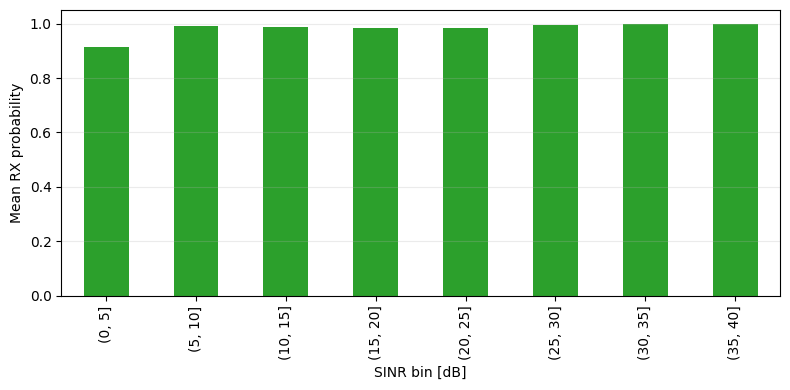

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
rx_by_sinr["mean"].plot(kind="bar", ax=ax, color="tab:green")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean RX probability")
ax.set_xlabel("SINR bin [dB]")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [14]:
handover_times = df.loc[df["serving_gnb"].diff().fillna(0) != 0, "time_s"].to_numpy()
high_sinr_mean_rxp = df.loc[df["sinr_db"] > 15, "rx_probability"].mean()

assert len(handover_times) >= 1, "No A3 handover happened in direct MultiGNBWrapper trace"
assert int(df["serving_gnb"].iloc[-1]) == 0, "UE did not finish on gNB1"
#assert len(handover_times) <= 3, f"Too many handovers / ping-pong: {len(handover_times)}"
assert env.get_handover_failure_ratios(), "HF ratio dict is empty"
assert env.get_ping_pong_ratios(), "PP ratio dict is empty"
assert high_sinr_mean_rxp >= 0.85, f"High SINR rx_probability too low: {high_sinr_mean_rxp:.3f}"
assert (df["used_prbs"] <= df["allocated_prbs"]).all(), "used_prbs cannot exceed allocated_prbs"
assert (df["wasted_prbs"] == df["allocated_prbs"] - df["used_prbs"]).all(), "PRB accounting mismatch"

print("PASS")
print(f"handover_times={handover_times}")
print(f"high_sinr_mean_rxp={high_sinr_mean_rxp:.3f}")
print(f"trace={TRACE_CSV}")


PASS
handover_times=[ 1.387 18.054 34.721 51.388]
high_sinr_mean_rxp=0.988
trace=/home/oussama/Desktop/chech/results/single_ue_3gnb_a3_rxprob_regression/radio_prb_trace_fixed.csv
